<a href="https://colab.research.google.com/github/tanvibeer12/Pattern-Recognition/blob/main/CM23020_pr_1_pr.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving Mall_Customers.csv to Mall_Customers.csv

Dataset 'Mall_Customers.csv' Preview:
   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Pattern Representation:
   Gender  Age  Annual Income (k$)  Spending Score (1-100)
0       1   19                  15                      39
1       1   21                  15                      81
2       0   20                  16                       6
3       0   23                  16                      77
4       0   31                  17                      40

----- Proximity Measures -----
Euclidean Distance : 42.04759208325728
Manhattan Distance : 44
Cosine Simila

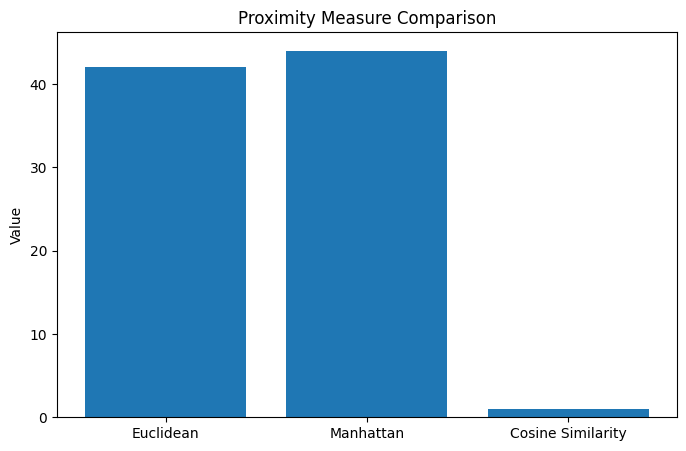

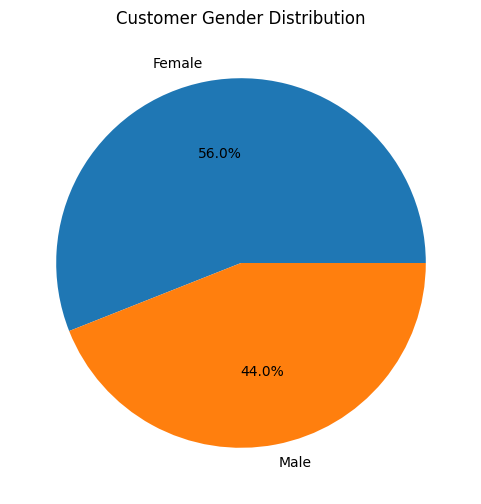

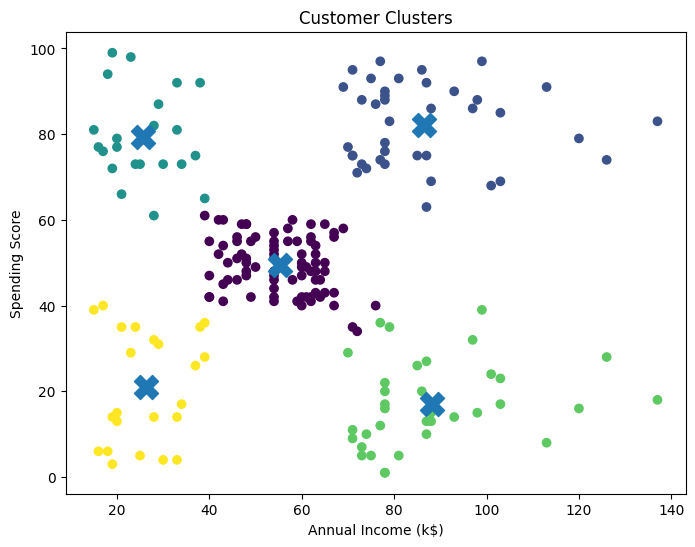


Practical Completed Successfully.


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics.pairwise import cosine_similarity
from scipy.spatial.distance import euclidean, cityblock
from sklearn.cluster import KMeans

# For file upload in Colab, we use google.colab.files
from google.colab import files
import io

# ==========================
# STEP 1 : Upload Dataset
# ==========================

# Use google.colab.files.upload() for Colab environment
uploaded = files.upload()

# Assuming only one file is uploaded, get its name
file_name = next(iter(uploaded))

# Read the uploaded CSV file into a pandas DataFrame
df = pd.read_csv(io.BytesIO(uploaded[file_name]))

print(f"\nDataset '{file_name}' Preview:")
print(df.head())

# ==========================
# STEP 2 : Pattern Representation
# ==========================

le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])

features = df[['Gender',
               'Age',
               'Annual Income (k$)',
               'Spending Score (1-100)']]

print("\nPattern Representation:")
print(features.head())

# ==========================
# STEP 3 : Similarity Measures
# ==========================

customer1 = features.iloc[0]
customer2 = features.iloc[1]

euclidean_dist = euclidean(customer1, customer2)

manhattan_dist = cityblock(customer1, customer2)

cosine_sim = cosine_similarity(
    [customer1],
    [customer2]
)[0][0]

print("\n----- Proximity Measures -----")
print("Euclidean Distance :", euclidean_dist)
print("Manhattan Distance :", manhattan_dist)
print("Cosine Similarity  :", cosine_sim)

# ==========================
# STEP 4 : Edit Distance
# ==========================

def edit_distance(str1, str2):

    m = len(str1)
    n = len(str2)

    dp = [[0]*(n+1) for _ in range(m+1)]

    for i in range(m+1):
        dp[i][0] = i

    for j in range(n+1):
        dp[0][j] = j

    for i in range(1,m+1):
        for j in range(1,n+1):

            if str1[i-1] == str2[j-1]:
                dp[i][j] = dp[i-1][j-1]

            else:
                dp[i][j] = 1 + min(
                    dp[i-1][j],
                    dp[i][j-1],
                    dp[i-1][j-1]
                )

    return dp[m][n]

profile1 = str(customer1.values)
profile2 = str(customer2.values)

print("\nEdit Distance :", edit_distance(profile1, profile2))

# ==========================
# Visualization 1
# BAR CHART
# ==========================

plt.figure(figsize=(8,5))

plt.bar(
    ['Euclidean','Manhattan','Cosine Similarity'],
    [euclidean_dist,
     manhattan_dist,
     cosine_sim]
)

plt.title("Proximity Measure Comparison")
plt.ylabel("Value")
plt.show()

# ==========================
# Visualization 2
# PIE CHART
# ==========================

gender_count = df['Gender'].value_counts()

plt.figure(figsize=(6,6))

plt.pie(
    gender_count,
    labels=['Female','Male'],
    autopct='%1.1f%%'
)

plt.title("Customer Gender Distribution")
plt.show()

# ==========================
# Visualization 3
# CLUSTERING
# ==========================

X = df[['Annual Income (k$)',
        'Spending Score (1-100)']]

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

df['Cluster'] = kmeans.fit_predict(X)

plt.figure(figsize=(8,6))

plt.scatter(
    X['Annual Income (k$)'],
    X['Spending Score (1-100)'],
    c=df['Cluster']
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.title("Customer Clusters")

plt.scatter(
    kmeans.cluster_centers_[:,0],
    kmeans.cluster_centers_[:,1],
    s=300,
    marker='X'
)

plt.show()

print("\nPractical Completed Successfully.")